# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [166]:
from __future__ import annotations

from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [167]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    B, C, H, W = x.shape
    x = x.view(B, C, H // patch_size, patch_size, W // patch_size, patch_size)
    x = torch.einsum('b c h p w q -> b h w c p q', x).contiguous()
    return x.view(B, H // patch_size * W // patch_size, patch_size * patch_size * C)

In [168]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.proj = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.proj(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(num_tokens, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.weights.unsqueeze(0)

In [169]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff, bias=True)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(d_ff, d_model, bias=True)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        return self.drop(x)


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.W = nn.Linear(d_model, d_ff_gated, bias=False)
        self.V = nn.Linear(d_model, d_ff_gated, bias=False)
        self.W2 = nn.Linear(d_ff_gated, d_model, bias=False)
        self.drop = nn.Dropout(dropout)
        self.variant = variant

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # GEGLU and SwiGLU -->> best perplexities
        if self.variant == 'GLU':
            return self.W2(self.drop(F.sigmoid(self.W(x)) * self.V(x)))
        elif self.variant == 'GEGLU':
            return self.W2(self.drop(F.gelu(self.W(x)) * self.V(x)))
        elif self.variant == 'SwiGLU':
            return self.W2(self.drop(F.silu(self.W(x)) * self.V(x)))
        else:
            raise ValueError(f'Unknown variant {self.variant}')

In [170]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.mlp = mlp
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.drop(self.attn(self.ln1(x), self.ln1(x), self.ln1(x))[0])
        x = x + self.drop(self.mlp(self.ln2(x)))
        return x

In [171]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        self.patch_embed = PatchEmbed(patch_dim, d_model)
        self.pos_embed = PositionalEmbedding(self.num_tokens, d_model)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=(
                    FeedForward(d_model, d_ff, dropout) if mlp_kind == 'FFN' else
                    GLUFeedForward(d_model, int(d_ff * 2 / 3), dropout, variant=mlp_kind) if mlp_kind in ['GLU', 'GEGLU', 'SwiGLU'] else
                    None
                ),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = patchify(x, self.patch_size)
        x = self.patch_embed(x)
        x = self.pos_embed(x)

        for block in self.blocks:
            x = block(x)

        x = x.mean(dim=1)
        return self.head(x)

In [172]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [173]:
from tqdm import trange
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in trange(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)
            
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "mlp_kind": mlp_kind,
        "train_losses": train_losses,
        "test_accs": test_accs,
    }

In [ ]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["FFN", "GEGLU", "SwiGLU"]
results = []

# for kind in runs:
#     # torch.manual_seed(cfg.seed)
    
#     train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
#     test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    
#     model = TinyViT(
#         patch_size=patch_size,
#         d_model=d_model,
#         n_heads=n_heads,
#         n_layers=n_layers,
#         d_ff=d_ff,
#         dropout=dropout,
#         mlp_kind=kind,
#     )
#     num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"\nRun: {kind} | " )
#     out = train_one_run(kind, model, train_loader, test_loader, cfg)
#     print(f"Number of parameters: {num_params} | Final test accuracy: {out['test_accs'][-1]:.4f} | Best test accuracy: {max(out['test_accs']):.4f}")
#     results.append(out)


Run: FFN | 


 20%|██        | 1/5 [00:40<02:42, 40.70s/it]

[FFN] epoch 1/5 | test acc: 0.8056


 40%|████      | 2/5 [01:21<02:02, 40.81s/it]

[FFN] epoch 2/5 | test acc: 0.8813


...

[SwiGLU] epoch 3/5 | test acc: 0.9374


 80%|████████  | 4/5 [02:28<00:36, 36.93s/it]

[SwiGLU] epoch 4/5 | test acc: 0.9494


100%|██████████| 5/5 [03:06<00:00, 37.27s/it]

[SwiGLU] epoch 5/5 | test acc: 0.9571
Number of parameters: 103946 | Final test accuracy: 0.9571 | Best test accuracy: 0.9571


In [157]:
results[0].keys()

dict_keys(['mlp_kind', 'train_losses', 'test_accs'])

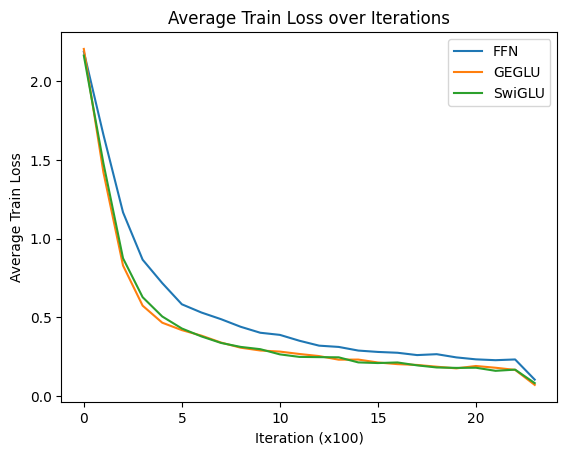

In [ ]:
# import matplotlib.pyplot as plt
# for res in results:
#     avg_train_losses = [sum(res['train_losses'][i:i+100])/100 for i in range(0, len(res['train_losses']), 100)]
#     plt.plot(avg_train_losses, label=res['mlp_kind'])
# plt.xlabel('Iteration (x100)')
# plt.ylabel('Average Train Loss')
# plt.title('Average Train Loss over Iterations')
# plt.legend()
# plt.show()

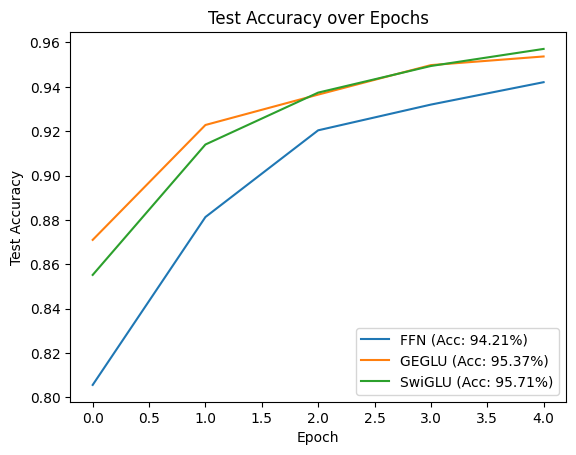

In [ ]:
# for res in results:
#     final_acc = res['test_accs'][-1]
#     plt.plot(res['test_accs'], label=f"{res['mlp_kind']} (Acc: {final_acc:.2%})")
# plt.xlabel('Epoch')
# plt.ylabel('Test Accuracy')
# plt.title('Test Accuracy over Epochs')
# plt.legend(loc='lower right')
# plt.show()